# Введение в анализ данных

**Цель работы** с данным файлом - визуализация результатов лабораторной работы.

Инструкция:
0. Создайте копию файла для работы (Файл -> Сохранить копию на Диске)
1. Оставьте только код, касающийся вашего варианта
2. Вставьте в раздел "Ожидается код студента (вариант Х)" код своей лабораторной работы (из попытки на moodle).
3. Запустите выполнение файла.
  - Доработайте файл, если этого требует задание к ЛР.
5. Скачайте файл (Файл -> Скачать -> Скачать IPYNB) **с результатами выполнения кода** и добавьте его в PullRequest своей работы.

## Вариант 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve

##### Ожидается код студента (вариант 2)

In [2]:
def load_data(train_size=0.7):
    iris = load_iris()
    X, y = iris.data, iris.target
    X = X[:, :3]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        train_size=train_size,
        random_state=42,
        stratify=y
    )
    return X_train, X_test, y_train, y_test

def convert_to_pandas(X, y):
    df = pd.DataFrame(X, columns=['sepal_length', 'sepal_width', 'petal_length'])
    target_series = pd.Series(y, name='species')
    return df, target_series

def explore_data(df, target_series):
    print(df.head())
    print(df.describe())
    print(target_series.value_counts())
    return None

def preprocess_data(X_train, X_test, scaler_type='standard'):
    if scaler_type == 'standard':
        scaler = StandardScaler()
    elif scaler_type == 'minmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'robust':
        scaler = RobustScaler()
    else:
        return None

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

def train_model(X_train, y_train, max_depth=5):
    """max_depth ограничивает глубину дерева: меньшие значения уменьшают переобучение, большие — повышают сложность модели."""
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)
    return model

def predict(model, X_test):
    return model.predict(X_test)

def evaluate(y_pred, y_test):
    """На точность повлияли: качество признаков, глубина дерева, тип предобработки и размер обучающей выборки."""
    score = accuracy_score(y_test, y_pred)
    return round(float(score), 3)


#### Подготовленный код для варианта 2

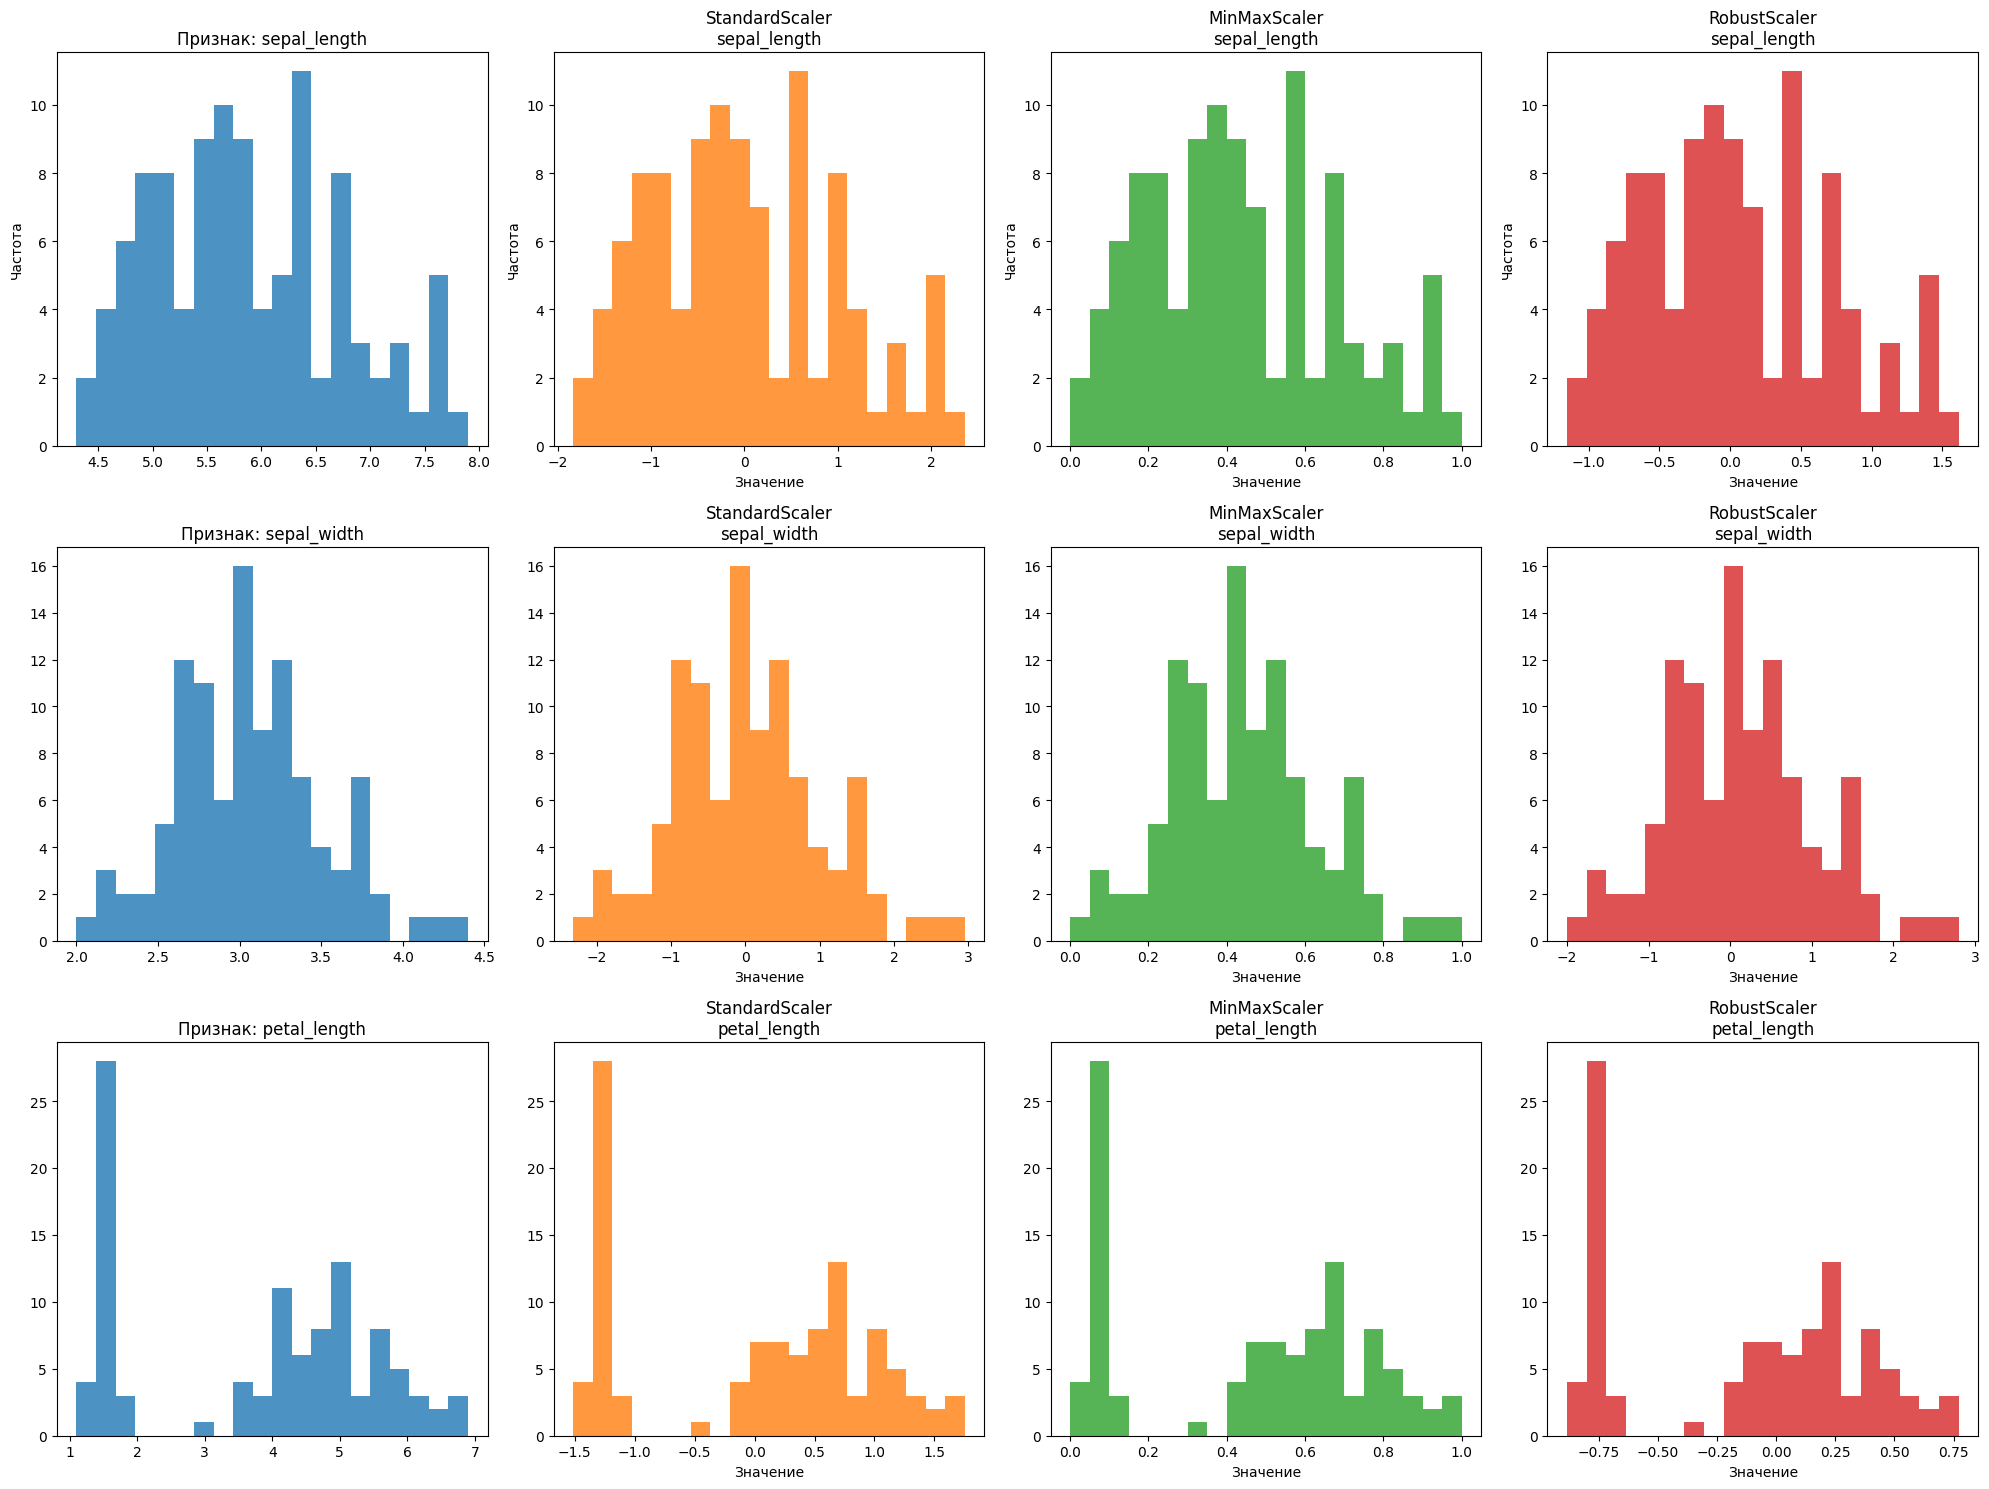

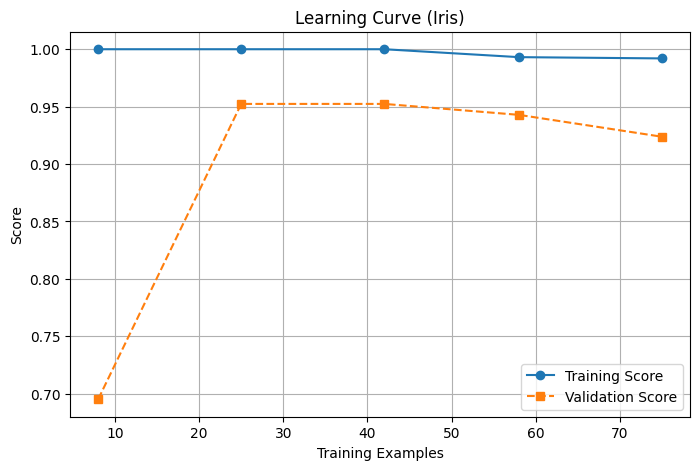

Исследование данных:
   sepal_length  sepal_width  petal_length
0           5.1          2.5           3.0
1           6.2          2.2           4.5
2           5.1          3.8           1.5
3           6.8          3.2           5.9
4           5.7          2.8           4.1
       sepal_length  sepal_width  petal_length
count    105.000000   105.000000    105.000000
mean       5.873333     3.055238      3.784762
std        0.862941     0.457203      1.784052
min        4.300000     2.000000      1.100000
25%        5.100000     2.800000      1.600000
50%        5.800000     3.000000      4.200000
75%        6.400000     3.300000      5.100000
max        7.900000     4.400000      6.900000
species
1    35
0    35
2    35
Name: count, dtype: int64


0.889

In [3]:
def main_iris():
    X_train, X_test, y_train, y_test = load_data()
    X_train_scaled, X_test_scaled = preprocess_data(X_train, X_test)
    feature_names = ['sepal_length', 'sepal_width', 'petal_length']
    # Выбираем три первых признака для визуализации
    feature_indices = [0, 1, 2]
    selected_features = [feature_names[i] for i in feature_indices]

    plt.figure(figsize=(20, 15))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # палитра

    # Список скейлеров для сравнения
    scalers = [
        ('StandardScaler', StandardScaler()),
        ('MinMaxScaler', MinMaxScaler()),
        ('RobustScaler', RobustScaler())
    ]

    # Построение гистограмм для каждого признака
    for row, feat_idx in enumerate(feature_indices, 1):
        original_feature = X_train[:, feat_idx]

        # Гистограмма до скейлинга
        plt.subplot(3, 4, (row-1)*4 + 1)
        plt.hist(original_feature, bins=20, color=colors[0], alpha=0.8)
        plt.title(f'Признак: {selected_features[row-1]}')
        if row == 1: plt.ylabel('Частота')

        # Гистограммы после скейлинга
        for col, (name, scaler) in enumerate(scalers, 2):
            scaled_data = scaler.fit_transform(X_train)
            scaled_feature = scaled_data[:, feat_idx]
            plt.subplot(3, 4, (row-1)*4 + col)
            plt.hist(scaled_feature, bins=20,
                    color=colors[col-1], alpha=0.8)
            plt.title(f'{name}\n{selected_features[row-1]}')
            plt.xlabel('Значение')
            if row == 1: plt.ylabel('Частота')

    plt.tight_layout()
    plt.show()

    model = train_model(X_train_scaled, y_train)

    # Кривые обучения (Learning Curve)
    train_sizes_abs, train_scores, test_scores = learning_curve(
            model, X_train_scaled, y_train, train_sizes=[0.1, 0.3, 0.5, 0.7, 0.9], cv=5, scoring='accuracy'
        )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes_abs, train_mean, marker='o', label="Training Score", linestyle='-')
    plt.plot(train_sizes_abs, test_mean, marker='s', label="Validation Score", linestyle='--')
    plt.xlabel("Training Examples")
    plt.ylabel("Score")
    plt.legend()
    plt.grid()
    plt.title("Learning Curve (Iris)")
    plt.show()
    df, target_series = convert_to_pandas(X_train, y_train)

    print("Исследование данных:")
    explore_data(df, target_series)

    y_pred = predict(model, X_test_scaled)
    accuracy = evaluate(y_pred, y_test)
    return accuracy
main_iris()